In [1]:
import polars as pl
import metabiome.io as mio
data_dir = "/Users/shen/Documents/GitHub/metabiome/test_data"
# Load from multiple file formats
mds = mio.from_files(
    obs="{}/input/metadata".format(data_dir),           # Sample metadata
    abundance="{}/input/RPKM.json".format(data_dir),   # Gene abundance profiles
    taxonomy="{}/input/taxonomy.json".format(data_dir), # Taxonomic annotations
    functional="{}/input/FG.json".format(data_dir),    # Functional groups
    sequences="{}/input/merged.fasta".format(data_dir), # Gene sequences
    id_mapping="{}/input/id_mapping.tsv".format(data_dir) # ID cross-references
)

# Check data dimensions
print(f"Data shape: {mds.shape}")  # (n_samples, n_features)

Data shape: (9522, 9484)


In [51]:
operon_abd_data_CD.X

SparseAbundanceMatrix(1523 samples × 90 features, density=0.2607)

In [2]:
# aggregrate by pfam_domain and taxa first
operon_abd_data = mds.groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median")
operon_abd_data_diseaseMean = operon_abd_data.groupby.obs("disease_group").agg("mean")


In [3]:
# operon_abd_data_CD = operon_abd_data.filter.obs(pl.col("disease_group") == "CD")
operon_abd_data_CD = mds.filter.obs(pl.col("disease_group") == "CD").groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median")
operon_abd_data_UC = mds.filter.obs(pl.col("disease_group") == "UC").groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median")
operon_abd_data_Healthy = mds.filter.obs(pl.col("disease_group") == "Healthy").groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median")


/Users/shen/Documents/GitHub/metabiome/src/metabiome/core/space.py:374: UserWarning: 1 filtered samples were not present in the matrix and were dropped
  warnings.warn(


In [18]:
operon_abd_data.var

species,pfam_domain,gc_id,msp_id,gene_category,domain,kingdom,phylum,class,order,family,genus,var
str,str,str,str,str,str,str,str,str,str,str,str,str
"""Adlercreutzia equolifaciens""","""PF02613""","""cohort_merged__SRR14610682__k1…","""msp_267""","""accessory""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Coriobacteriia""","""Eggerthellales""","""Eggerthellaceae""","""Adlercreutzia""","""Adlercreutzia equolifaciens"""
"""Klebsiella oxytoca""","""PF02613""","""Germany__8626__k141_37519::133…","""msp_0161""","""core""","""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Klebsiella""","""Klebsiella oxytoca"""
"""Actinomyces sp. ICM47""","""PF02613""","""Israel__10107__k141_56279::1::…","""msp_0557""","""shared_accessory""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Actinomycetes""","""Actinomycetales""","""Actinomycetaceae""","""Actinomyces""","""Actinomyces sp. ICM47"""
"""uncultured Bilophila sp.""","""PF02613""","""cohort_merged__ERR4333894__k14…","""msp_0736""","""accessory""","""Bacteria""","""Pseudomonadati""","""Thermodesulfobacteriota""","""Desulfovibrionia""","""Desulfovibrionales""","""Desulfovibrionaceae""","""Bilophila""","""uncultured Bilophila sp."""
"""uncultured Ancrocorticia sp.""","""PF02665""","""Israel__10055__k141_58905::1::…","""msp_1509""","""core""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Actinomycetes""","""Actinomycetales""","""Actinomycetaceae""","""Ancrocorticia""","""uncultured Ancrocorticia sp."""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Propionibacterium acidifaciens""","""PF13247:::PF14711""","""France__9894__k141_69858::22::…","""msp_1338""","""core""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Actinomycetes""","""Propionibacteriales""","""Propionibacteriaceae""","""Propionibacterium""","""Propionibacterium acidifaciens"""
"""Candidatus Aveggerthella excre…","""PF02613""","""France__9855__k141_68382::54::…","""msp_0970""","""core""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Coriobacteriia""","""Eggerthellales""","""Eggerthellaceae""","""Candidatus Aveggerthella""","""Candidatus Aveggerthella excre…"
"""uncultured Collinsella sp.""","""PF02613""","""cohort_merged__SRR5650100__k99…","""msp_259""","""core""","""Bacteria""","""Bacillati""","""Actinomycetota""","""Coriobacteriia""","""Coriobacteriales""","""Coriobacteriaceae""","""Collinsella""","""uncultured Collinsella sp."""


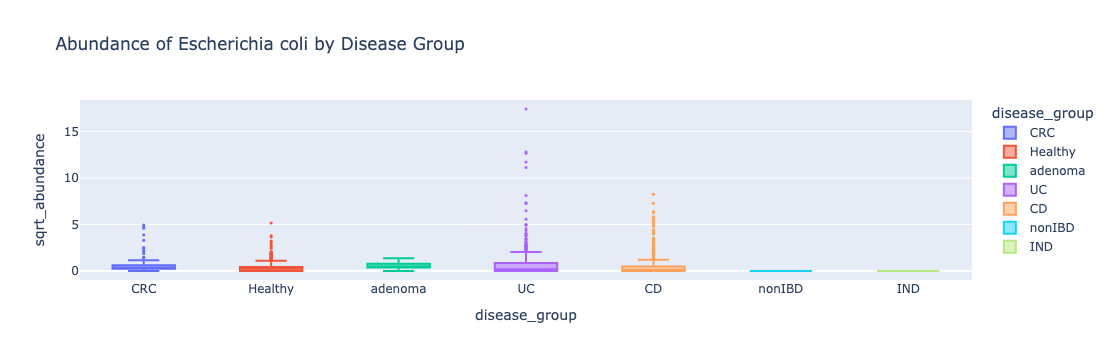

In [19]:
operon_abd_data.pl.boxplot(
    feature_name="Veillonella parvula",
    x_axis_col="disease_group",
    feature_type_col=None,
    title="Abundance of Escherichia coli by Disease Group",
    
)

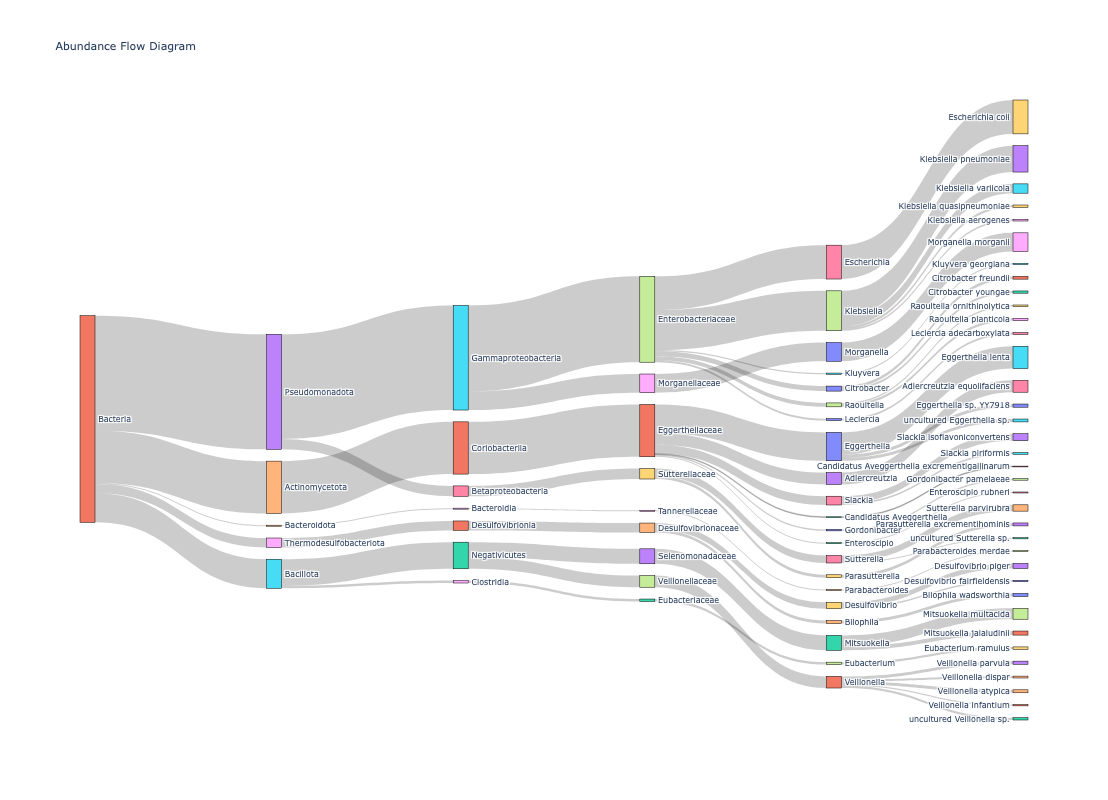

In [6]:
operon_abd_data_Healthy.pl.sankey(
    hierarchy_cols=["domain","phylum","class","family","genus", "species"], min_abundance=0.1
)

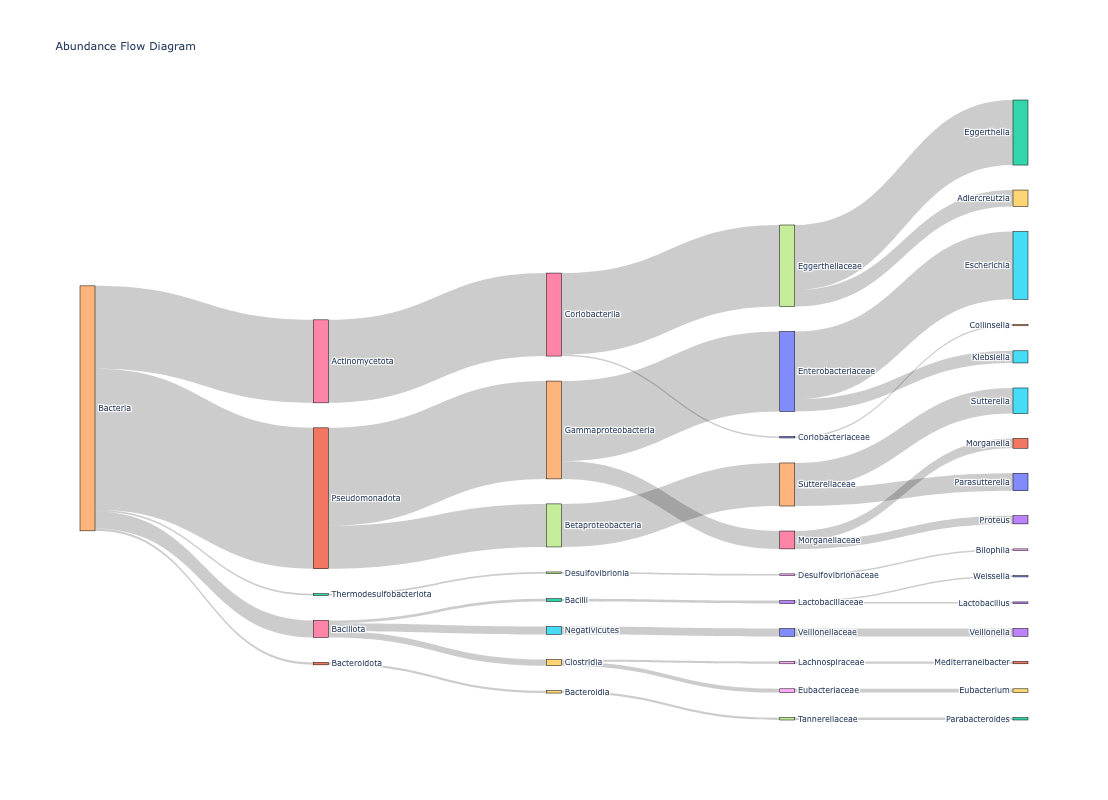

In [7]:
operon_abd_data_CD = mds.filter.obs(pl.col("disease_group") == "CD").groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median")
operon_abd_data_CD_alter = mds.groupby.var(["pfam_domain","species"]).agg("sum").groupby.var(["species"]).agg("median").filter.obs(pl.col("disease_group") == "CD")
operon_abd_data_CD_alter.pl.sankey(
    hierarchy_cols=["domain","phylum","class","family","genus"], min_abundance=0.1
)

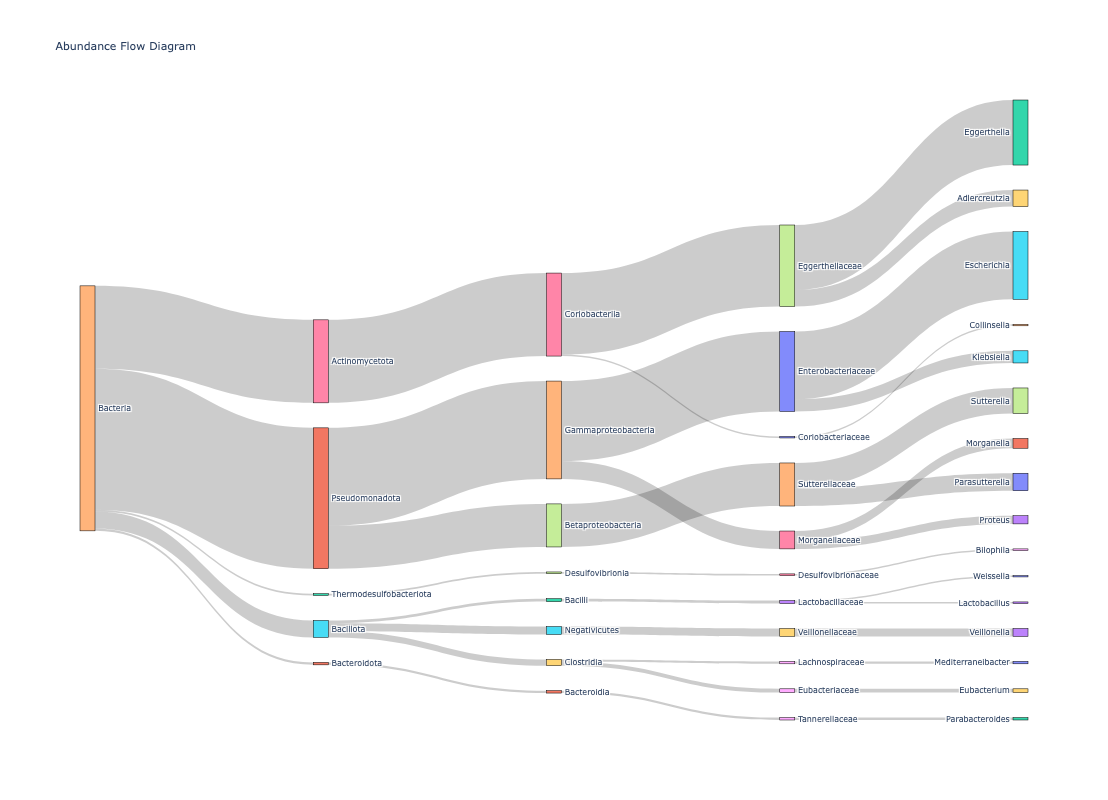

In [8]:
operon_abd_data_CD.pl.sankey(
    hierarchy_cols=["domain","phylum","class","family","genus"], min_abundance=0.1
)

In [9]:
type(mds.obs["age"])
mds.obs = mds.obs.with_columns([
    pl.col("age").cast(pl.Float64, strict=False)
])

In [10]:
mds.obs = mds.obs.with_columns(
    (pl.col("age") > 70).alias("age_gt_70")
)

In [11]:
mds.obs

sample,disease_group,disease_state,use_antibiotic,age,gender,age_gt_70
str,cat,cat,cat,f64,cat,bool
"""SRR8865580""","""CRC""",null,"""no""",67.0,"""M""",false
"""SRR8865577""","""CRC""",null,"""no""",71.0,"""M""",true
"""SRR8865593""","""CRC""",null,"""no""",72.0,"""M""",true
"""SRR8865575""","""CRC""",null,"""no""",60.0,"""M""",false
"""SRR8865594""","""CRC""",null,"""no""",48.0,"""M""",false
…,…,…,…,…,…,…
"""12675.FIT344E3CAL""","""CD""",null,"""0""",70.0,"""F""",false
"""12675.FIT074E3CAL""","""CD""",null,"""1""",27.0,"""F""",false
"""12675.FIT191E3CAL""","""CD""",null,"""1""",66.0,"""M""",false


In [12]:
# Single sample and feature
sample_slice = mds["CSM5MCWG", "cohort_merged__MSM79HBR_k105_18694::129::153944::157684::+"]

# Multiple samples, all features
multi_samples = mds[["CSM5MCWG", "SRR7989845"], :]

# All samples, specific features
multi_features = mds[:, ["gene_1", "gene_2", "gene_3"]]

# Conditional filtering with Polars expressions
male_samples = mds[pl.col("gender") == "M", :]

# Chained indexing
filtered = mds[["CSM5MCWG", "SRR7989845"], :][
    :, ["gene_1", "gene_2"]
]

In [13]:
# Filter samples by metadata
male_samples = mds.filter.obs(pl.col("gender") == "M")

# Filter features by annotations
lactobacillus = mds.filter.var(pl.col("genus") == "Lactobacillaceae")

# Filter by abundance statistics
high_abundance = mds.filter.X("var", pl.col("mean_abundance") > 0.1)

In [13]:
grouped = mds.groupby.obs(["disease_group"])
disease_means = grouped.agg("mean")

In [14]:
disease_means.collect()

GroupedMetabiomeDataSpace(obs=['disease_group'], state=aggregated)

In [22]:
from metabiome.pl import plot_sankey
healthy_mds = mds.filter.obs(pl.col("disease_group") == "Healthy")
cd_mds = mds.filter.obs(pl.col("disease_group") == "CD")
uc_mds = mds.filter.obs(pl.col("disease_group") == "UC")

/Users/shen/Documents/GitHub/metabiome/src/metabiome/core/space.py:313: UserWarning:

175 filtered samples were not present in the matrix and were dropped

/Users/shen/Documents/GitHub/metabiome/src/metabiome/core/space.py:313: UserWarning:

319 filtered samples were not present in the matrix and were dropped

/Users/shen/Documents/GitHub/metabiome/src/metabiome/core/space.py:313: UserWarning:

207 filtered samples were not present in the matrix and were dropped



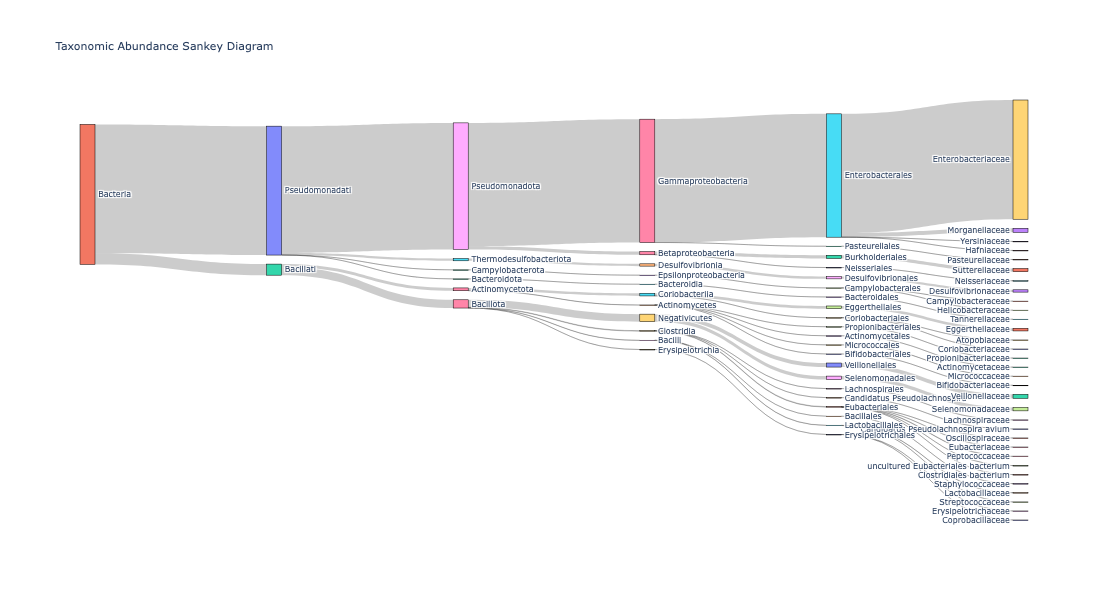

In [23]:
plot_sankey(healthy_mds, max_level="genus", min_abundance=0.01, height=600)

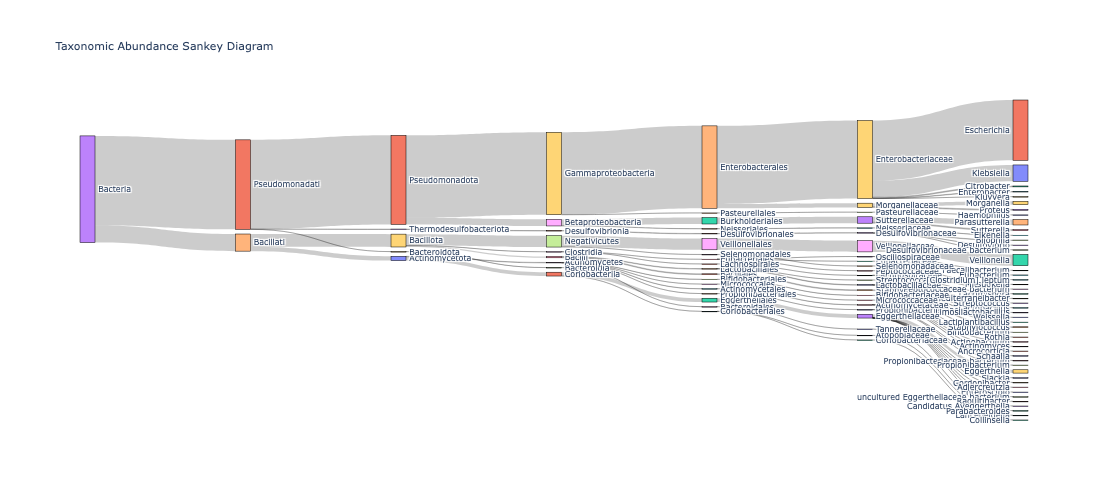

In [24]:
plot_sankey(cd_mds, max_level="species", min_abundance=0.01, height=500)

InvalidOperationError: 'is_in' cannot check for List(String) values in List(List(String)) data

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
FILTER col("domain").is_in([["", "NA"]]).not()
FROM
  FILTER col("domain").is_not_null()
  FROM
    SELECT [col("domain"), col("kingdom"), col("phylum"), col("order"), col("family"), col("genus"), col("var")]
      DF ["species", "pfam_domain", "gc_id", "msp_id", ...]; PROJECT */13 COLUMNS

In [34]:
operon_abd_data.X[1:10,]

ValueError: Indexing must be a 2-tuple of (rows, cols)